# Data Jobs Analysis in the Middle East

In [1]:
# Importing Libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns   
import ast
from datasets import load_dataset

# Loading Data
# Load the job postings dataset directly from Hugging Face
ds = load_dataset("lukebarousse/data_jobs")
# Convert the training split into a pandas DataFrame
df=ds['train'].to_pandas()


# Data Cleanup
# Parse the job_posted_date column as datetime for time-based analysis
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
# job_skills is stored as a stringified list — convert it back to an actual Python list
# Skip null values to avoid errors
df['job_skills']= df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)



In [2]:
# Define the countries considered part of the Middle East for this analysis
middle_east=['Algeria', 'Bahrain', 'Egypt', 'Iraq', 'Jordan', 'Kuwait', 'Lebanon', 'Libya', 'Morocco', 'Oman', 'Palestine', 'Qatar', 'Saudi Arabia', 'Tunisia', 'Turkey', 'United Arab Emirates','Yemen']

# Filter the dataset to Middle East jobs only; .copy() prevents SettingWithCopyWarning
df_me=df[df['job_country'].isin(middle_east)].copy()
df_me.info()


<class 'pandas.DataFrame'>
Index: 21481 entries, 83 to 785686
Data columns (total 17 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   job_title_short        21481 non-null  str           
 1   job_title              21481 non-null  str           
 2   job_location           21481 non-null  str           
 3   job_via                21481 non-null  str           
 4   job_schedule_type      21398 non-null  str           
 5   job_work_from_home     21481 non-null  bool          
 6   search_location        21481 non-null  str           
 7   job_posted_date        21481 non-null  datetime64[us]
 8   job_no_degree_mention  21481 non-null  bool          
 9   job_health_insurance   21481 non-null  bool          
 10  job_country            21481 non-null  str           
 11  salary_rate            101 non-null    str           
 12  salary_year_avg        87 non-null     float64       
 13  salary_hour_avg

## Skills Analysis for Top Data Roles

-------------------------------------------------------------------------------------------


## What are the most demanded skills for top 3 populer data roles?


In [3]:
# Explode the job_skills list so each skill gets its own row
# This allows skill-level aggregation and counting
df_Skills = df_me.explode('job_skills')

# Drop rows where job_skills is null after exploding
df_Skills = df_Skills[df_Skills['job_skills'].notna()]
df_Skills


,job_title_short,job_title,job_location,job_via,job_schedule_type,job_work_from_home,search_location,job_posted_date,job_no_degree_mention,job_health_insurance,job_country,salary_rate,salary_year_avg,salary_hour_avg,company_name,job_skills,job_type_skills
83,Software Engineer,Senior DevOps Engineer,Egypt (+1 other),via Levels.fyi,Full-time,False,Egypt,2023-11-01 13:13:36,False,False,Egypt,NaN,NaN,NaN,2U,bash,"{'analyst_tools': ['splunk'], 'cloud': ['aws']..."
83,Software Engineer,Senior DevOps Engineer,Egypt (+1 other),via Levels.fyi,Full-time,False,Egypt,2023-11-01 13:13:36,False,False,Egypt,NaN,NaN,NaN,2U,python,"{'analyst_tools': ['splunk'], 'cloud': ['aws']..."
83,Software Engineer,Senior DevOps Engineer,Egypt (+1 other),via Levels.fyi,Full-time,False,Egypt,2023-11-01 13:13:36,False,False,Egypt,NaN,NaN,NaN,2U,aws,"{'analyst_tools': ['splunk'], 'cloud': ['aws']..."
83,Software Engineer,Senior DevOps Engineer,Egypt (+1 other),via Levels.fyi,Full-time,False,Egypt,2023-11-01 13:13:36,False,False,Egypt,NaN,NaN,NaN,2U,linux,"{'analyst_tools': ['splunk'], 'cloud': ['aws']..."
83,Software Engineer,Senior DevOps Engineer,Egypt (+1 other),via Levels.fyi,Full-time,False,Egypt,2023-11-01 13:13:36,False,False,Egypt,NaN,NaN,NaN,2U,splunk,"{'analyst_tools': ['splunk'], 'cloud': ['aws']..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
785587,Business Analyst,Business Intelligence Analyst,Egypt,via Trabajo.org,Full-time,False,Egypt,2023-12-07 06:20:16,False,False,Egypt,NaN,NaN,NaN,Ingram Micro,python,"{'analyst_tools': ['power bi', 'dax'], 'progra..."
785587,Business Analyst,Business Intelligence Analyst,Egypt,via Trabajo.org,Full-time,False,Egypt,2023-12-07 06:20:16,False,False,Egypt,NaN,NaN,NaN,Ingram Micro,power bi,"{'analyst_tools': ['power bi', 'dax'], 'progra..."
785587,Business Analyst,Business Intelligence Analyst,Egypt,via Trabajo.org,Full-time,False,Egypt,2023-12-07 06:20:16,False,False,Egypt,NaN,NaN,NaN,Ingram Micro,dax,"{'analyst_tools': ['power bi', 'dax'], 'progra..."
785667,Business Analyst,HR Analyst Jobs,Sharjah - United Arab Emirates,via Gulfcareers,Full-time,False,United Arab Emirates,2023-01-25 06:47:27,False,False,United Arab Emirates,NaN,NaN,NaN,Air Arabia,excel,"{'analyst_tools': ['excel', 'sap']}"


In [4]:
# Count how many times each skill appears for each job title
df_skills_count = df_Skills.groupby(['job_title_short','job_skills']).size()
df_skills_count=df_skills_count.reset_index(name='skill count')

# Sort by skill count descending to see the most common skills first
df_skills_count.sort_values(['skill count'],ascending=False, inplace=True)


df_skills_count


,job_title_short,job_skills,skill count
392,Data Analyst,sql,2109
693,Data Scientist,python,1794
555,Data Engineer,sql,1770
297,Data Analyst,excel,1721
527,Data Engineer,python,1528
...,...,...,...
2,Business Analyst,angular,1
557,Data Engineer,sqlite,1
518,Data Engineer,play framework,1
150,Cloud Engineer,bitbucket,1


In [12]:
# Get total job count per title to use as denominator for percentage calculation
df_top_data_jobs = df_me['job_title_short'].value_counts().reset_index()
df_top_data_jobs.columns = ['job_title_short', 'job count']

# Merge job counts with skill counts so we can compute percentage per role
df_skills_percent=pd.merge(df_top_data_jobs, df_skills_count, on='job_title_short', how='right')

# Calculate what percent of jobs for a given role mention each skill
df_skills_percent['skill percent']=(df_skills_percent['skill count']/df_skills_percent['job count'])*100
df_skills_percent


,job_title_short,job count,job_skills,skill count,skill percent
0,Data Analyst,5892,sql,2109,35.794297
1,Data Scientist,3871,python,1794,46.344614
2,Data Engineer,3547,sql,1770,49.901325
3,Data Analyst,5892,excel,1721,29.209097
4,Data Engineer,3547,python,1528,43.078658
...,...,...,...,...,...
1442,Business Analyst,2683,angular,1,0.037272
1443,Data Engineer,3547,sqlite,1,0.028193
1444,Data Engineer,3547,play framework,1,0.028193
1445,Cloud Engineer,620,bitbucket,1,0.161290


In [13]:
df_top_data_jobs

,job_title_short,job count
0,Data Analyst,5892
1,Data Scientist,3871
2,Data Engineer,3547
3,Business Analyst,2683
4,Software Engineer,1857
5,Senior Data Engineer,936
6,Senior Data Scientist,841
7,Senior Data Analyst,695
8,Cloud Engineer,620
9,Machine Learning Engineer,539


In [14]:
# Extract the top 3 most common job titles as a list for iteration
job_titles = df_top_data_jobs['job_title_short'].tolist()
job_titles = job_titles[:3]
job_titles


['Data Analyst', 'Data Scientist', 'Data Engineer']

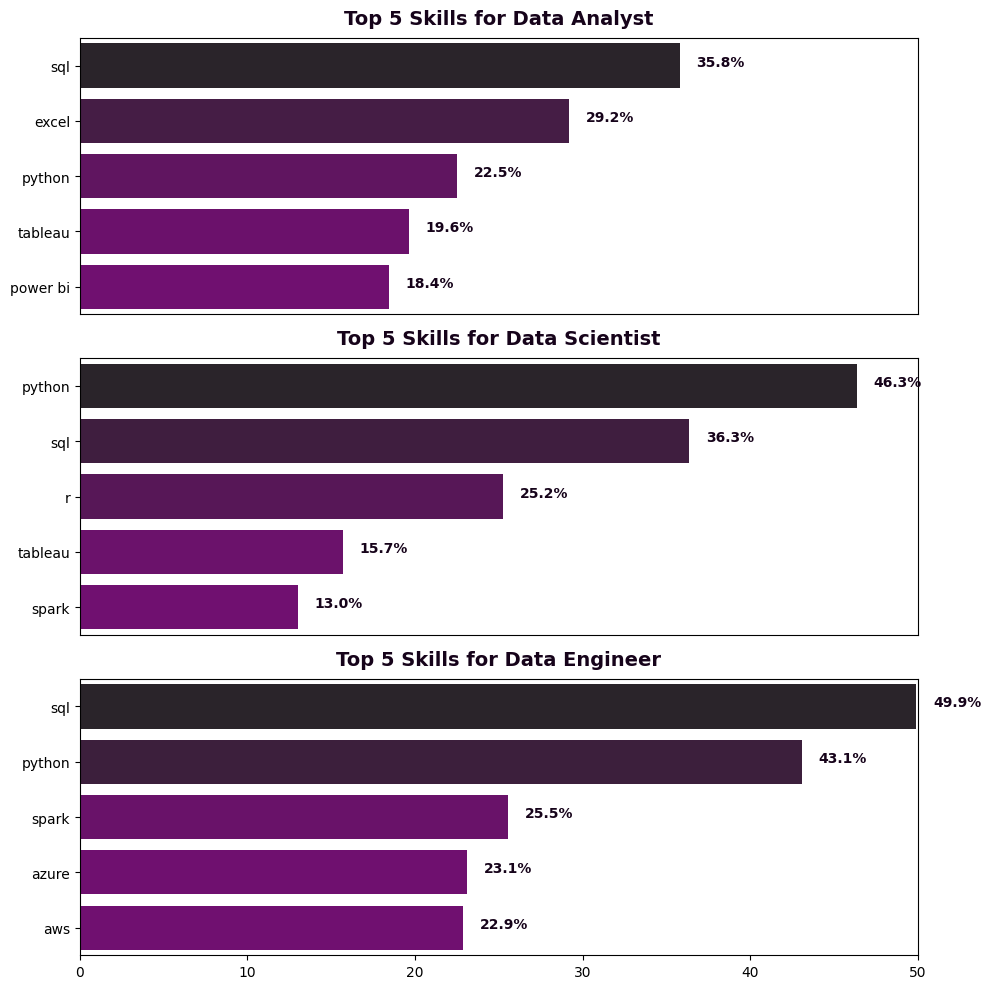

In [15]:
# Create one subplot per job title, stacked vertically
fig,ax = plt.subplots(len(job_titles),1,figsize=(10,10))


for i,job in enumerate(job_titles):
    # Get the top 5 skills for the current job title
    df_top5_skills  = df_skills_percent[df_skills_percent['job_title_short'] == job].head(5)
    sns.barplot(data=df_top5_skills,
                x='skill percent',
                y='job_skills',
                hue='skill percent',
                ax=ax[i],
                legend=False,
                palette='dark:purple_r')

    ax[i].set_ylabel('')
    ax[i].set_xlabel('')
    ax[i].set_title(f'Top 5 Skills for {job}',fontsize=14,loc='center',color="#16031a",fontweight='bold',pad=10)
    # Fix x-axis to 50% so all subplots use the same scale for easy comparison
    ax[i].set_xlim(0,50)

    # Annotate each bar with its percentage value
    for n,v in enumerate(df_top5_skills['skill percent']):
        ax[i].text(v+1, n, f"{v:.1f}%", color="#16031a", fontweight='bold')

    # Remove x-axis ticks from all but the last subplot to reduce clutter
    if i != len(job_titles)-1:
     ax[i].set_xticks([])

fig.tight_layout()
plt.show()



## How are in demand skills Trending for Data Analyst?

In [16]:
# Filter to Data Analyst jobs only for the trending analysis
df_trend_skills = df_Skills[df_Skills['job_title_short'] == 'Data Analyst']

# Extract the posting month as a number (1–12) for monthly grouping
df_trend_skills['job_posted_month'] = df_trend_skills['job_posted_date'].dt.month

# Create a pivot table: rows = month, columns = skill, values = count of appearances
df_trend_skills_pivot=df_trend_skills.pivot_table(index='job_posted_month', columns='job_skills', aggfunc='size', fill_value=0)


In [17]:
# Add a total row to identify the most mentioned skills across all months
df_trend_skills_pivot.loc['total']=df_trend_skills_pivot.sum()

# Sort columns by total count descending so the most popular skills appear first
df_trend_skills_pivot=df_trend_skills_pivot[df_trend_skills_pivot.loc['total'].sort_values(ascending=False).index]

# Remove the total row — it was only needed for sorting
df_trend_skills_pivot=df_trend_skills_pivot.drop('total')

# Keep only the top 5 skills
df_trend_skills_pivot=df_trend_skills_pivot.iloc[:,:5]
df_trend_skills_pivot


job_skills,sql,excel,python,tableau,power bi
job_posted_month,,,,,
1,213,154,127,106,82
2,106,99,75,57,67
3,104,88,77,56,70
4,130,100,76,73,67
5,133,101,73,69,53
6,147,135,102,89,72
7,176,145,115,104,90
8,284,240,167,162,170
9,230,169,132,120,90


In [18]:
# Count total Data Analyst job postings per month — used as denominator for percentages
df_total_jobs=df_trend_skills.groupby('job_posted_month').size()


In [19]:
# Divide skill counts by total monthly job count (as percent) to normalize across months
df_trend_skills_percent =df_trend_skills_pivot.div(df_total_jobs/100, axis=0)

df_trend_skills_percent


job_skills,sql,excel,python,tableau,power bi
job_posted_month,,,,,
1,13.043478,9.430496,7.777097,6.491121,5.021433
2,11.534276,10.772579,8.161045,6.202394,7.290533
3,11.698538,9.898763,8.661417,6.299213,7.874016
4,13.415893,10.319917,7.843137,7.533540,6.914345
5,15.776987,11.981020,8.659549,8.185053,6.287070
6,12.997347,11.936340,9.018568,7.869142,6.366048
7,14.035088,11.562998,9.170654,8.293461,7.177033
8,14.024691,11.851852,8.246914,8.000000,8.395062
9,17.280240,12.697220,9.917355,9.015778,6.761833


In [20]:
# Convert month numbers to abbreviated month names (e.g., 1 → 'Jan') for readable x-axis labels
df_trend_skills_percent= df_trend_skills_percent.reset_index()
df_trend_skills_percent['job_posted_month'] = df_trend_skills_percent['job_posted_month'].apply(lambda x:pd.to_datetime(x,format='%m').strftime('%b'))
df_trend_skills_percent=df_trend_skills_percent.set_index('job_posted_month')
df_trend_skills_percent


job_skills,sql,excel,python,tableau,power bi
job_posted_month,,,,,
Jan,13.043478,9.430496,7.777097,6.491121,5.021433
Feb,11.534276,10.772579,8.161045,6.202394,7.290533
Mar,11.698538,9.898763,8.661417,6.299213,7.874016
Apr,13.415893,10.319917,7.843137,7.533540,6.914345
May,15.776987,11.981020,8.659549,8.185053,6.287070
Jun,12.997347,11.936340,9.018568,7.869142,6.366048
Jul,14.035088,11.562998,9.170654,8.293461,7.177033
Aug,14.024691,11.851852,8.246914,8.000000,8.395062
Sep,17.280240,12.697220,9.917355,9.015778,6.761833


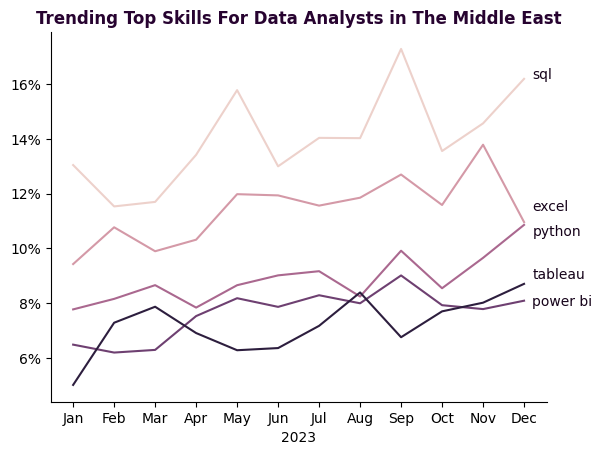

In [21]:

# Plot the monthly skill trend as a line chart
sns.lineplot(
    data = df_trend_skills_percent,
    dashes=False, legend=False,
    palette=sns.cubehelix_palette(n_colors=5))

plt.title('Trending Top Skills For Data Analysts in The Middle East',color="#270330",fontweight='bold')
plt.xlabel('2023')
sns.despine()

# Add skill name labels at the end of each line with slight vertical offsets to avoid overlap
offsets = [0, 0.4, -0.4, 0.8, -0.8]
for i in range(5):
    plt.text(
        11.2,
        df_trend_skills_percent.iloc[-1,i] + offsets[i],
        df_trend_skills_percent.columns[i],
        color="#16031a"
        )
    
# Format y-axis as percentages
from matplotlib.ticker import PercentFormatter    
ax = plt.gca()
ax.yaxis.set_major_formatter(PercentFormatter(decimals=0))

plt.show()
